# Attention Visualizer

This notebook demonstrates the basic idea of self-attention in a Transformer.

Given a sentence, we calculate how strongly each word attends to every other word and visualize the attention weights as a heatmap.

The notebook demonstrates:

- Query, Key, and Value
- Attention scores
- Softmax
- Attention weights
- Weighted sum
- Self-attention
- Attention heatmap

In [27]:
sentence = 'the autofocus motor worked because of spi clock.'
print (sentence)

the autofocus motor worked because of spi clock.


In [28]:
words = sentence.split()
print(words)
print('no of words: ', len(words))

['the', 'autofocus', 'motor', 'worked', 'because', 'of', 'spi', 'clock.']
no of words:  8


In [29]:
pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import numpy as np
import matplotlib.pyplot as plt


## Word Embeddings

A neural network works with numerical vectors rather than raw words.

For this educational example, we assign each word a small random vector.

In a real Transformer, these representations would be learned embeddings produced by the model.

In [31]:
np.random.seed(2)
embedding_dim = 4
embeddings = np.random.randn(len(words), embedding_dim)
print('embedding shape: ',embeddings.shape)

embedding shape:  (8, 4)


In [32]:
for word , vector in zip(words, embeddings):
    print(word, '->' , vector)

the -> [-0.41675785 -0.05626683 -2.1361961   1.64027081]
autofocus -> [-1.79343559 -0.84174737  0.50288142 -1.24528809]
motor -> [-1.05795222 -0.90900761  0.55145404  2.29220801]
worked -> [ 0.04153939 -1.11792545  0.53905832 -0.5961597 ]
because -> [-0.0191305   1.17500122 -0.74787095  0.00902525]
of -> [-0.87810789 -0.15643417  0.25657045 -0.98877905]
spi -> [-0.33882197 -0.23618403 -0.63765501 -1.18761229]
clock. -> [-1.42121723 -0.1534952  -0.26905696  2.23136679]


## Query, Key, and Value

For each word, we create three representations:

- Query: what information this word is looking for
- Key: what information this word offers for matching
- Value: the information that will be collected

Attention first compares Queries with Keys.
The resulting weights are then used to combine the Values.

In [33]:
np.random.seed(42)

W_Q = np.random.randn(embedding_dim,embedding_dim)
W_K = np.random.randn(embedding_dim,embedding_dim)
W_V = np.random.randn(embedding_dim,embedding_dim)

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

print('Q shape: ',Q.shape)
print('k shape: ', K.shape)
print('v shape: ', V.shape)


Q shape:  (8, 4)
k shape:  (8, 4)
v shape:  (8, 4)


## Attention Scores

Every word compares its Query with the Key of every word.

The score tells us how strongly one word matches another word.

Conceptually:

Attention Scores = Q × Kᵀ

In [34]:
scores = Q @ K.T

print('scores matrix shape: ', scores.shape)
print(scores)

scores matrix shape:  (8, 8)
[[ -1.66946444  -3.72440755  -1.16532799  -3.61694857   3.15712937
   -1.20194285  -2.50741886   0.31173406]
 [-12.7411199   -6.86393322 -20.33562819   1.9118581    1.27126882
   -0.96902362   3.11502868 -21.77520457]
 [-19.78490646 -17.43849914 -18.08861444  -1.89716397   2.63453138
   -6.13161337  -5.6022183  -21.6140978 ]
 [ -5.30382638  -2.86420647  -5.09382154   0.93946776  -0.40512574
   -0.84893945  -0.26219558  -6.53164179]
 [  8.16109205   5.79156952   6.75971334  -0.50446393   0.14153001
    2.05477957   1.72653497   8.90737889]
 [ -3.75965036  -1.00822385  -8.39031731   1.38488076   0.27683992
    0.43615916   2.68416646  -8.60612689]
 [  2.26772421   3.46884184  -1.31001202   0.6880372    0.21609837
    1.87235432   2.95836472  -0.11176377]
 [-15.44767531 -14.21637612 -16.1804904   -2.40672193   3.35260541
   -4.70446504  -3.89787485 -17.9879178 ]]


## Scaling the Attention Scores

The dot products can become large when the vector dimension increases.

To keep the values at a more useful scale, Transformer attention divides the scores by the square root of the key dimension.

Scaled scores:

QKᵀ / √d

In [35]:
scaled_scores = scores / np.sqrt(embedding_dim)
print(scaled_scores)

[[ -0.83473222  -1.86220377  -0.58266399  -1.80847429   1.57856468
   -0.60097142  -1.25370943   0.15586703]
 [ -6.37055995  -3.43196661 -10.1678141    0.95592905   0.63563441
   -0.48451181   1.55751434 -10.88760228]
 [ -9.89245323  -8.71924957  -9.04430722  -0.94858199   1.31726569
   -3.06580669  -2.80110915 -10.8070489 ]
 [ -2.65191319  -1.43210324  -2.54691077   0.46973388  -0.20256287
   -0.42446973  -0.13109779  -3.26582089]
 [  4.08054603   2.89578476   3.37985667  -0.25223196   0.07076501
    1.02738979   0.86326749   4.45368945]
 [ -1.87982518  -0.50411192  -4.19515866   0.69244038   0.13841996
    0.21807958   1.34208323  -4.30306344]
 [  1.13386211   1.73442092  -0.65500601   0.3440186    0.10804918
    0.93617716   1.47918236  -0.05588188]
 [ -7.72383765  -7.10818806  -8.0902452   -1.20336097   1.67630271
   -2.35223252  -1.94893743  -8.9939589 ]]


## Softmax

Softmax converts the raw attention scores into normalized attention weights.

For each word, its attention weights across all words should add up to 1.

Formula:

softmax(xᵢ) = exp(xᵢ) / Σ exp(xⱼ)

In [36]:
def softmax(x):
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

In [37]:
test_scores = np.array([231.0 , 451.0, 564.0])
test_weights = softmax(test_scores)

print('scores : ', test_scores)
print("softmax weights: ", test_weights)
print('sum: ', np.sum(test_weights))

scores :  [231. 451. 564.]
softmax weights:  [2.39848787e-145 8.40859712e-050 1.00000000e+000]
sum:  1.0


In [38]:
aw = np.zeros_like(scaled_scores)

for i in range(len(words)):
    aw[i] = softmax(scaled_scores[i])
print('the attention weights are: ', aw)

the attention weights are:  [[5.31719736e-02 1.90308223e-02 6.84155181e-02 2.00813070e-02
  5.93969725e-01 6.71744014e-02 3.49722272e-02 1.43184025e-01]
 [1.73086299e-04 3.26947156e-03 3.88272087e-06 2.63097327e-01
  1.90991588e-01 6.23075850e-02 4.80155168e-01 1.89032349e-06]
 [1.19565686e-05 3.86475916e-05 2.79223323e-05 9.15968395e-02
  8.82928694e-01 1.10250733e-02 1.43660762e-02 4.79074118e-06]
 [1.61243832e-02 5.46059342e-02 1.79095668e-02 3.65760841e-01
  1.86733586e-01 1.49571729e-01 2.00566931e-01 8.72702825e-03]
 [2.96481045e-01 9.06695901e-02 1.47126673e-01 3.89309822e-03
  5.37738539e-03 1.39967764e-02 1.18781996e-02 4.30577232e-01]
 [1.69517842e-02 6.70934448e-02 1.67370480e-03 2.21991401e-01
  1.27564004e-01 1.38141407e-01 4.25081748e-01 1.50250667e-03]
 [1.57726791e-01 2.87557597e-01 2.63639158e-02 7.15946864e-02
  5.65458291e-02 1.29435077e-01 2.22779973e-01 4.79961297e-02]
 [7.51307762e-05 1.39056436e-04 5.20821735e-05 5.10064292e-02
  9.08336912e-01 1.61687462e-02 2.4

In [39]:
row_sums = np.sum(aw, axis = 1)
print(row_sums)

[1. 1. 1. 1. 1. 1. 1. 1.]


In [41]:
import pandas as pd

In [44]:
attention_df = pd.DataFrame(
    
    aw,index= words, columns = words
)

attention_df

,the,autofocus,motor,worked,because,of,spi,clock.
the,0.053172,0.019031,0.068416,0.020081,0.593970,0.067174,0.034972,0.143184
autofocus,0.000173,0.003269,0.000004,0.263097,0.190992,0.062308,0.480155,0.000002
motor,0.000012,0.000039,0.000028,0.091597,0.882929,0.011025,0.014366,0.000005
worked,0.016124,0.054606,0.017910,0.365761,0.186734,0.149572,0.200567,0.008727
because,0.296481,0.090670,0.147127,0.003893,0.005377,0.013997,0.011878,0.430577
of,0.016952,0.067093,0.001674,0.221991,0.127564,0.138141,0.425082,0.001503
spi,0.157727,0.287558,0.026364,0.071595,0.056546,0.129435,0.222780,0.047996
clock.,0.000075,0.000139,0.000052,0.051006,0.908337,0.016169,0.024201,0.000021


## Weighted Sum of Values

The attention weights tell us how much information each word should take from every other word.

We use these weights to calculate a weighted sum of the Value vectors.

Conceptually:

Attention Output = Attention Weights × V

In [45]:
attention_output = aw @ V
print('attention output shape:', attention_output.shape)

attention output shape: (8, 4)


In [46]:
attention_output_df = pd.DataFrame(
    attention_output,
    index=words
)

attention_output_df

,0,1,2,3
the,-0.908765,-1.046545,-1.208392,1.226966
autofocus,0.917093,1.131428,0.479879,-0.523344
motor,-0.151009,-1.844998,-1.152130,0.323975
worked,0.776001,1.393368,0.437489,-0.276108
because,-2.937933,0.422477,-1.170514,3.172243
of,1.003494,1.514579,0.453453,-0.382926
spi,0.252719,1.849193,-0.017681,0.686992
clock.,-0.181170,-1.988642,-1.254453,0.372691


## Most Attended Word

For each word, we find the word that received the highest attention weight.

The result is based on the attention weights calculated above.

In [48]:
most_attended = []

for i, word in enumerate(words):
    attention_row = aw[i]

    # Find the position of the largest attention weight
    max_index = np.argmax(attention_row)

    most_attended.append({
        "Word": word,
        "Most attended word": words[max_index],
        "Attention weight": round(attention_row[max_index], 3)
    })

most_attended_df = pd.DataFrame(most_attended)

most_attended_df

,Word,Most attended word,Attention weight
0,the,because,0.594
1,autofocus,spi,0.480
2,motor,because,0.883
3,worked,worked,0.366
4,because,clock.,0.431
5,of,spi,0.425
6,spi,autofocus,0.288
7,clock.,because,0.908


# Attention Heatmap

The heatmap shows the attention weight between every pair of words.

- Rows represent the word asking for information.
- Columns represent the words being attended to.
- Larger attention weights appear as stronger regions in the heatmap.

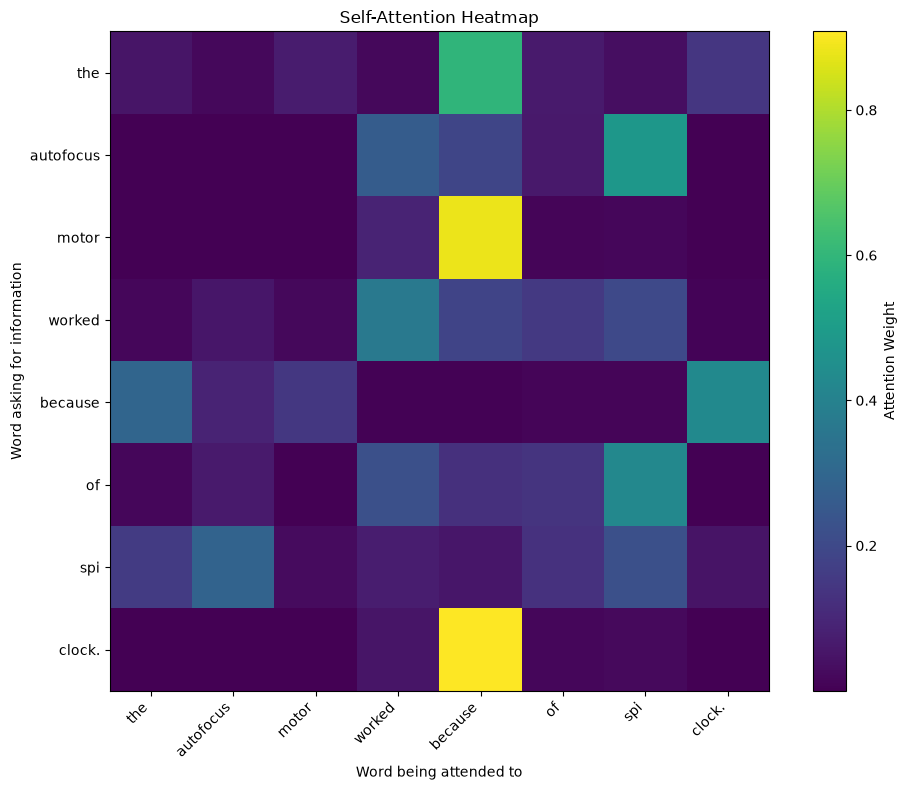

: 

In [ ]:
plt.figure(figsize=(10, 8))

plt.imshow(aw)

plt.xticks(
    range(len(words)),
    words,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(words)),
    words
)

plt.xlabel("Word being attended to")
plt.ylabel("Word asking for information")
plt.title("Self-Attention Heatmap")

plt.colorbar(label="Attention Weight")

plt.tight_layout()
plt.show()

### Note

This notebook implements self-attention from scratch for educational purposes.

The initial example uses randomly initialized embeddings and projection matrices. Therefore, the resulting attention patterns demonstrate the mathematical mechanism of attention but should not be interpreted as learned semantic relationships.

A trained Transformer would learn meaningful attention patterns from data.